In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import pandas as pd
chilled_fish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity': [2773,1578,3183,2624,3088,3820,3284,3350,3779,3988,5060,7200,6541,21453,28817,21118,21278,26868,19755,31404,33150,31815,19501,17207,21202,17622,21689,24428],
'Price':[26.08,18.74,44.31,29.18,44.97,71.63,63.66,59.14,64.03,68.14,81.56,117.3,118.11,217.34,264.49,257.54,357.42,537.11,527.84,635.93,809.5,769.81,647.41,616.22,631.84,477.99,733.47,616.29]}
df7=pd.DataFrame(chilled_fish)

Dataset has 28 records and 3 columns


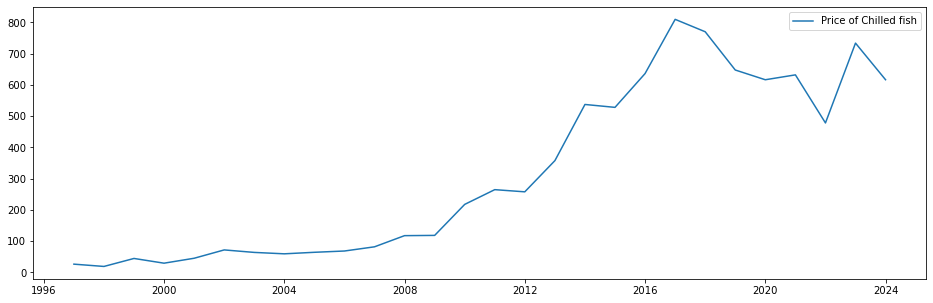

Results of Dickey-Fuller Test:
Test Statistic                 -0.798048
p-value                         0.819695
#Lags Used                      0.000000
Number of Observations Used    27.000000
Critical Value (1%)            -3.699608
Critical Value (5%)            -2.976430
Critical Value (10%)           -2.627601
dtype: float64


In [3]:
# Check the dimensionality of the dataset
df7.shape
print("Dataset has {} records and {} columns".format(df7.shape[0], df7.shape[1]))
# Changing the YEAR data type and setting it as index
df7['YEAR'] = pd.Index(sm.tsa.datetools.dates_from_range('1996', '2023'))
df7.index = df7['YEAR']
# Check the data type
del df7['YEAR']
# View the dataset
df7.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df7.index, df7['Price'], label = "Price of Chilled fish")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df7test = adfuller(timeseries, autolag='AIC')
    df7output = pd.Series(df7test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df7test[4].items():
        df7output['Critical Value (%s)'%key] = value
    print (df7output)
# Call the function and run the test

adf_test(df7['Price'])


In [6]:
df7['Price_diff']=df7['Price'].diff()
df7=df7.dropna()

In [7]:

#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df7test = adfuller(df7['Price_diff'],autolag='AIC')
df7output=pd.Series(df7test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df7test[4].items():
    df7output['critical value (%s)'%key]= value
print(df7output)

Results of Dickey-fuller test:
Test Statistic :                 -2.243918
p-value :                         0.190693
#lags used :                      9.000000
number of observations used :    17.000000
critical value (1%)              -3.889266
critical value (5%)              -3.054358
critical value (10%)             -2.666984
dtype: float64


In [8]:
df7['Price_diff_2']=df7['Price_diff'].diff()
df7=df7.dropna()

In [9]:

#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df7test = adfuller(df7['Price_diff_2'],autolag='AIC')
df7output=pd.Series(df7test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df7test[4].items():
    df7output['critical value (%s)'%key]= value
print(df7output)

Results of Dickey-fuller test:
Test Statistic :                 -1.030195
p-value :                         0.742093
#lags used :                      9.000000
number of observations used :    16.000000
critical value (1%)              -3.924019
critical value (5%)              -3.068498
critical value (10%)             -2.673893
dtype: float64


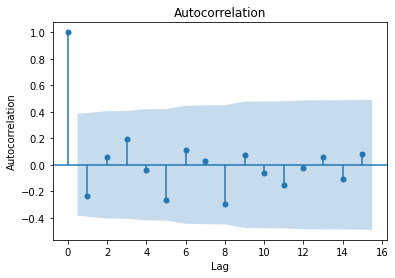

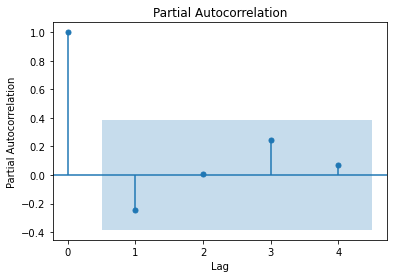

In [11]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df7['Price_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=4)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df7['Price_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=4)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

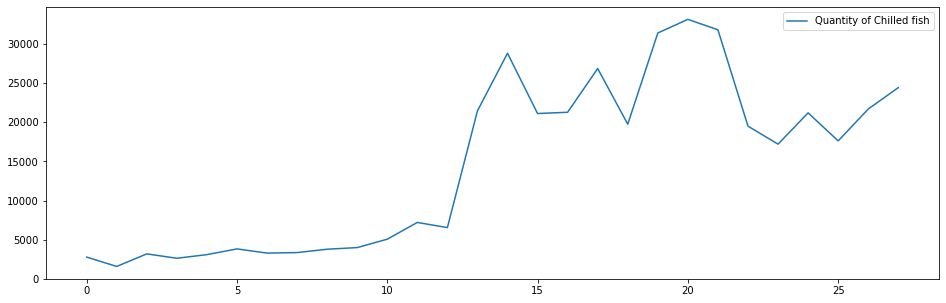

Results of Dickey-fuller test:
Test Statistic :                 -1.358751
p-value :                         0.601884
#lags used :                      0.000000
number of observations used :    27.000000
critical value (1%)              -3.699608
critical value (5%)              -2.976430
critical value (10%)             -2.627601
dtype: float64


In [79]:
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df7.index, df7['Quantity'], label = "Quantity of Chilled fish")
plt.legend(loc='best')
plt.show()
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df7test = adfuller(df7['Quantity'],autolag='AIC')
df7output=pd.Series(df7test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df7test[4].items():
    df7output['critical value (%s)'%key]= value
print(df7output)

In [80]:
df7['Quantity_diff']=df7['Quantity'].diff()
df7=df7.dropna()


In [81]:
#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df7test = adfuller(df7['Quantity_diff'],autolag='AIC')
df7output=pd.Series(df7test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df7test[4].items():
    df7output['critical value (%s)'%key]= value
print(df7output)

Results of Dickey-fuller test:
Test Statistic :                 -5.321074
p-value :                         0.000005
#lags used :                      0.000000
number of observations used :    26.000000
critical value (1%)              -3.711212
critical value (5%)              -2.981247
critical value (10%)             -2.630095
dtype: float64


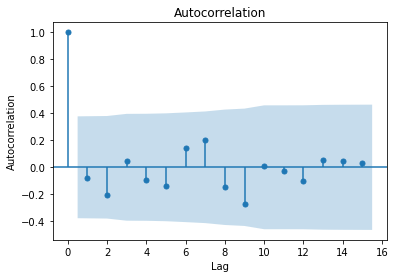

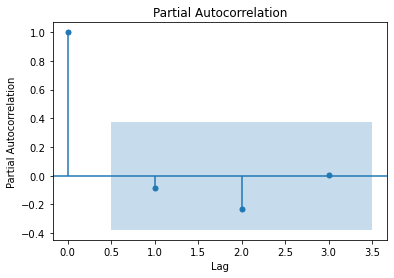

In [84]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df7['Quantity_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=3)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

In [18]:
#2 nd objectieve
#Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
variable1_with_constant = sm.add_constant(df7['Quantity'])

# Fit the OLS model
model = sm.OLS(df7['Price'], variable1_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())


Cointegrating Relationship:
Price = -5.184790113670652 + 0.02228486848649243 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     75.65
Date:                Sun, 16 Jul 2023   Prob (F-statistic):           4.95e-09
Time:                        23:07:03   Log-Likelihood:                -170.98
No. Observations:                  27   AIC:                             346.0
Df Residuals:                      25   BIC:                             348.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [86]:
# 3rd obj VAR model
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

# Extract the variables of interest
variables = df7[['Quantity', 'Price']]

# Create a VAR model with a specified lag order (p)
model = VAR(variables)
results = model.fit(maxlags=2) 
print(model)
parameters = results.params
print("Parameter Estimates:")
print(parameters)
print("\n")
# Print the estimated coefficients
print("Estimated Coefficients:")
print(results.coefs)

# Forecast future values
n_periods = 10  # Number of periods to forecast
forecast = results.forecast(variables.values[-2:], steps=n_periods)  # Specify the appropriate lag order

# Print the forecasted values
print("Forecasted Values:")
print(forecast)



Parameter Estimates:
                Quantity      Price
const        3044.574429  18.865948
L1.Quantity     0.734988   0.004698
L1.Price        9.472654   0.467422
L2.Quantity     0.060907   0.001602
L2.Price       -7.384773   0.283527


Estimated Coefficients:
[[[ 7.34987592e-01  9.47265362e+00]
  [ 4.69753318e-03  4.67421570e-01]]

 [[ 6.09069840e-02 -7.38477324e+00]
  [ 1.60214240e-03  2.83527425e-01]]]
Forecasted Values:
[[22741.25497131   664.39225509]
 [22989.34626253   650.11727028]
 [22578.50949825   655.54615435]
 [22448.50353064   652.50394042]
 [22259.01901281   651.35225519]
 [22123.38851667   648.8529837 ]
 [21996.99105567   646.41752602]
 [21891.21595183   643.75947292]
 [21798.58056128   641.12713373]
 [21718.74613812   638.53846606]]


In [2]:
import pandas as pd
chilled_fish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity': [2773,1578,3183,2624,3088,3820,3284,3350,3779,3988,5060,7200,6541,21453,28817,21118,21278,26868,19755,31404,33150,31815,19501,17207,21202,17622,21689,24428],
'Price':[26.08,18.74,44.31,29.18,44.97,71.63,63.66,59.14,64.03,68.14,81.56,117.3,118.11,217.34,264.49,257.54,357.42,537.11,527.84,635.93,809.5,769.81,647.41,616.22,631.84,477.99,733.47,616.29]}
df7=pd.DataFrame(chilled_fish)

In [3]:
# Assuming you have a DataFrame 'data' containing the price and quantity variables.
# We'll use the ADF test to check for stationarity.
from statsmodels.tsa.stattools import adfuller
data=df7[['Price','Quantity']]
def are_series_stationary(data, threshold=0.05):
    result = adfuller(data)
    p_value = result[1]
    return p_value <= threshold

# Test for stationarity of price and quantity
is_price_stationary = are_series_stationary(df7['Price'])
is_quantity_stationary = are_series_stationary(df7['Quantity'])

# If both series are non-stationary, proceed with cointegration test
if not is_price_stationary and not is_quantity_stationary:
    result = coint_johansen(data, det_order=0, k_ar_diff=1)

    # Get the trace statistics and critical values for different significance levels (e.g., 90%, 95%, 99%)
    trace_statistic = result.lr1
    trace_critical_values = result.cvt[:, 1]  # Use 1% critical value (you can choose other values as well)

    # Find the number of cointegrated vectors (relationships)
    num_cointegrated_vectors = sum(trace_statistic > trace_critical_values)

    if num_cointegrated_vectors > 0:
        print("The variables price and quantity are cointegrated.")
    else:
        print("The variables price and quantity are not cointegrated.")
else:
    print("Both variables should be non-stationary for cointegration testing.")


NameError: name 'coint_johansen' is not defined

In [4]:
num_cointegrated_vectors

NameError: name 'num_cointegrated_vectors' is not defined

In [5]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
variables=df7[['Price','Quantity']]
# Extract the variables
variables = df7[[ 'Quantity','Price']]

# Perform Johansen cointegration test
coint_result = coint_johansen(variables, det_order=-1, k_ar_diff=1)

# Extract the cointegrating vectors
coint_vectors = coint_result.evec

# Specify the number of cointegrating vectors to use for prediction
num_coint_vectors = 1

# Create the VECM model using the cointegrating vectors
model = VECM(variables, k_ar_diff=1, coint_rank=num_coint_vectors, deterministic='nc')
model_fit = model.fit()
print(model)
# Generate predictions for the next 'n' steps
n = 10
forecast = model_fit.predict(steps=10)

# Print the forecasted values
print("Forecasted Values:")
print(forecast)
model_fit.predict(10, 0.05)

Forecasted Values:
[[23373.95234675   669.74687824]
 [23746.75099947   657.90665843]
 [23592.33719951   668.73867898]
 [23636.80147754   669.90620518]
 [23609.96899714   673.649116  ]
 [23611.5982055    675.62369229]
 [23604.29037692   677.59945991]
 [23601.60273004   679.04751869]
 [23598.25233057   680.2667092 ]
 [23595.99416079   681.22885111]]


(array([[23373.95234675,   669.74687824],
        [23746.75099947,   657.90665843],
        [23592.33719951,   668.73867898],
        [23636.80147754,   669.90620518],
        [23609.96899714,   673.649116  ],
        [23611.5982055 ,   675.62369229],
        [23604.29037692,   677.59945991],
        [23601.60273004,   679.04751869],
        [23598.25233057,   680.2667092 ],
        [23595.99416079,   681.22885111]]),
 array([[12705.55863613,   511.24774293],
        [ 9096.17607642,   458.75903209],
        [ 5997.20377044,   408.36538696],
        [ 3488.55860432,   353.2297129 ],
        [ 1242.27409574,   298.64806835],
        [ -767.57000551,   243.70608871],
        [-2618.3196679 ,   189.85358503],
        [-4335.57756574,   137.15008169],
        [-5947.3395955 ,    85.95513042],
        [-7470.02395645,    36.32984198]]),
 array([[34042.34605737,   828.24601354],
        [38397.32592251,   857.05428477],
        [41187.47062858,   929.11197101],
        [43785.04435075,   986

In [6]:
coint_vectors

array([[ 1.75542262e-04, -7.84726984e-05],
       [-6.04222164e-03,  5.60508105e-03]])

In [7]:
vecm_res = model.fit()
vecm_res.gamma.round()
vecm_res.summary()
print(model)
vecm_res.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,-0.0877,0.267,-0.328,0.743,-0.611,0.436
L1.Price,5.5509,15.613,0.356,0.722,-25.051,36.153
,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,-0.0017,0.004,-0.432,0.666,-0.009,0.006
L1.Price,-0.2986,0.232,-1.287,0.198,-0.753,0.156
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-0.0509,0.187,-0.271,0.786,-0.418,0.316
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,0.0072,0.003,2.588,0.010,0.002,0.013
,coef,std err,z,P>|z|,[0.025,0.975]


lower bounds of confidence intervals:
[[12705.559   511.248]
 [ 9096.176   458.759]
 [ 5997.204   408.365]
 [ 3488.559   353.23 ]
 [ 1242.274   298.648]]

point forecasts:
[[23373.952   669.747]
 [23746.751   657.907]
 [23592.337   668.739]
 [23636.801   669.906]
 [23609.969   673.649]]

upper bounds of confidence intervals:
[[34042.346   828.246]
 [38397.326   857.054]
 [41187.471   929.112]
 [43785.044   986.583]
 [45977.664  1048.65 ]]


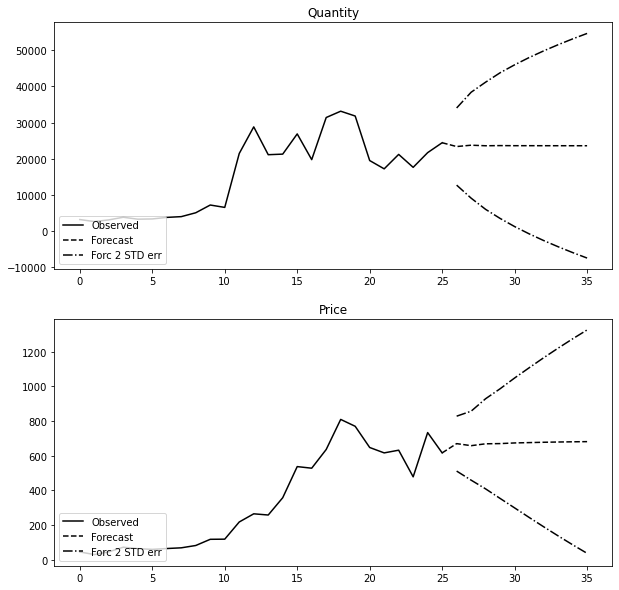

In [8]:
vecm_res.predict(steps=5)
forecast, lower, upper = vecm_res.predict(5, 0.05)
print("lower bounds of confidence intervals:")
print(lower.round(3))
print("\npoint forecasts:")
print(forecast.round(3))
print("\nupper bounds of confidence intervals:")
print(upper.round(3))
vecm_res.plot_forecast(steps=10)
